# Задание 2. Бифуркационный анализ модели химической кинетики (Модель № 4)

### Этап 1: Аналитические методы продолжения по параметру (стр. 5-12)

Для нахождения стационарных состояний приравняем правые части системы дифференциальных уравнений к нулю:
$$\frac{dx}{dt}=k_1 z-k_{-1}x-k_3 x+k_{-3}y-k_2 z^2 x=0$$
$$\frac{dy}{dt}=k_3 x-k_{-3}y=0$$
где $z=1-x-y$ — концентрация свободных мест на катализаторе.

Из второго уравнения легко выразить $y$ через $x$:
$$y=\frac{k_3}{k_{-3}}x$$
Тогда концентрация свободных мест выражается как:
$$z=1-x\left(1+\frac{k_3}{k_{-3}}\right)$$

Подставляя $y$ и $z$ в первое уравнение, мы можем аналитически выразить параметр $k_1$ как функцию от стационарной концентрации $x$:
$$k_1(x)=\frac{k_{-1}x+k_2 z^2 x}{z}$$
Этот подход позволяет нам построить зависимость стационарных решений от параметра (S-образную кривую), избегая численных проблем, связанных с многозначностью функции $x(k_1)$.

### Этап 2 и 3: Исследование матрицы Якоби и поиск точек бифуркаций

Для анализа устойчивости стационарных решений вычислим элементы матрицы Якоби $J$:
$$J_{11}=\frac{\partial f}{\partial x}=-k_1-k_{-1}-k_3-k_2 z^2+2k_2 z x$$
$$J_{12}=\frac{\partial f}{\partial y}=-k_1+k_{-3}+2k_2 z x$$
$$J_{21}=\frac{\partial g}{\partial x}=k_3$$
$$J_{22}=\frac{\partial g}{\partial y}=-k_{-3}$$

Характер устойчивости определяется следом ($\text{Tr}$) и определителем ($\text{Det}$) матрицы Якоби:
$$\text{Tr}(J)=J_{11}+J_{22}$$
$$\text{Det}(J)=J_{11}J_{22}-J_{12}J_{21}$$

**Условия бифуркаций:**
1. **Седло-узел (Saddle-Node):** Происходит при смене знака определителя ($\text{Det}(J)=0$). Геометрически это точки поворота на S-образной кривой.
2. **Бифуркация Андронова-Хопфа (Hopf):** Происходит, когда след матрицы пересекает ноль ($\text{Tr}(J)=0$) при условии $\text{Det}(J)>0$.

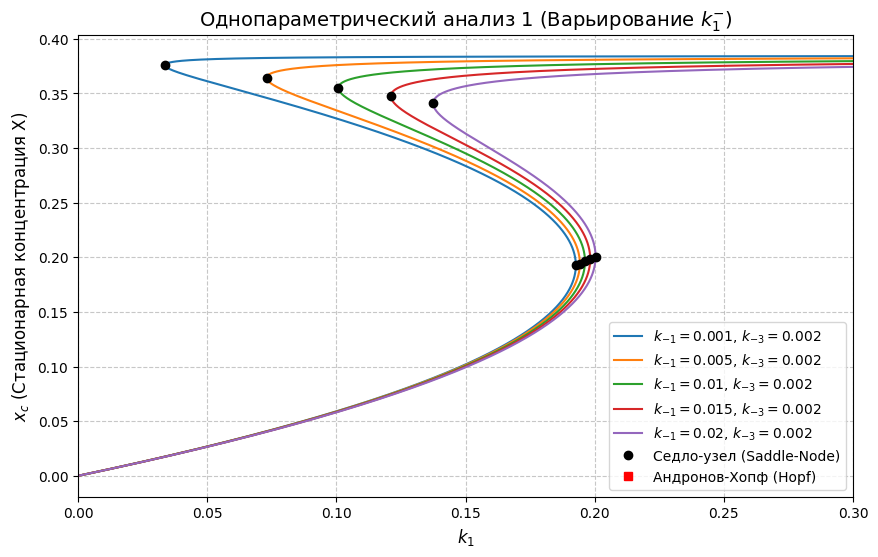

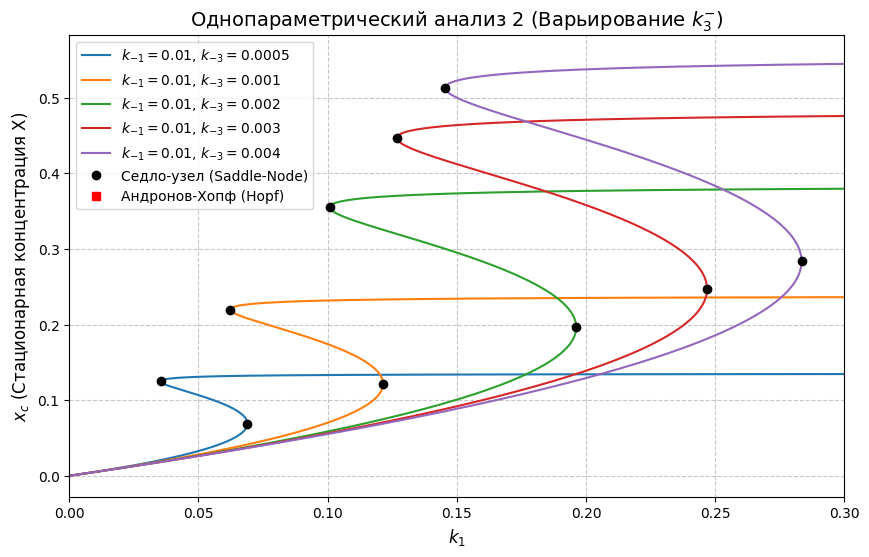

In [1]:
import numpy as np
import matplotlib.pyplot as plt


k2 = 2.0
k3 = 0.0032

def run_one_parameter_analysis(k1m_vals, k3m_vals, title):
    plt.figure(figsize=(10, 6))
    
    for k1m, k3m in zip(k1m_vals, k3m_vals):
        # 1. Аналитические методы продолжения
        C = k3 / k3m
        x_max = 1.0 / (1.0 + C)
        x = np.linspace(0.0001, x_max - 0.0001, 5000)
        
        y = C * x
        z = 1.0 - x - y
        k1 = (k1m * x + k2 * (z**2) * x) / z

        # 2. Исследование следа и определителя
        J11 = -k1 - k1m - k3 - k2 * (z**2) + 2 * k2 * z * x
        J12 = -k1 + k3m + 2 * k2 * z * x
        J21 = np.full_like(x, k3)
        J22 = np.full_like(x, -k3m)

        Tr = J11 + J22
        Det = J11 * J22 - J12 * J21

        # 3. Поиск точек бифуркаций
        sn_idx = np.where(np.diff(np.sign(Det)))[0] 
        hopf_idx = np.where((np.diff(np.sign(Tr)) != 0) & (Det[:-1] > 0))[0]

        # Построение графиков
        label_str = f'$k_{{-1}}={k1m}$, $k_{{-3}}={k3m}$'
        plt.plot(k1, x, label=label_str, linewidth=1.5)

        if len(sn_idx) > 0:
            plt.plot(k1[sn_idx], x[sn_idx], 'ko', markersize=6, zorder=5)
        if len(hopf_idx) > 0:
            plt.plot(k1[hopf_idx], x[hopf_idx], 'rs', markersize=6, zorder=5)

    # Легенда для маркеров
    plt.plot([], [], 'ko', label='Седло-узел (Saddle-Node)')
    plt.plot([], [], 'rs', label='Андронов-Хопф (Hopf)')
    
    plt.title(title, fontsize=14)
    plt.xlabel('$k_1$', fontsize=12)
    plt.ylabel('$x_c$ (Стационарная концентрация X)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(0, 0.3)
    plt.show()

# Задание 1.2.1: варьируем k1^- (в коде это k1m)
k1m_list = [0.001, 0.005, 0.01, 0.015, 0.02]
k3m_fixed = [0.002] * len(k1m_list)
run_one_parameter_analysis(k1m_list, k3m_fixed, "Однопараметрический анализ 1 (Варьирование $k_{1}^{-}$)")

# Задание 1.2.2: варьируем k3^- (в коде это k3m)
k3m_list = [0.0005, 0.001, 0.002, 0.003, 0.004]
k1m_fixed = [0.01] * len(k3m_list)
run_one_parameter_analysis(k1m_fixed, k3m_list, "Однопараметрический анализ 2 (Варьирование $k_{3}^{-}$)")

### Двухпараметрический анализ: Построение параметрического портрета

На плоскости параметров $(k_1, k_2)$ построим кривые, разделяющие области с различным динамическим поведением:

1. **Линия кратности:** Строится из условия $\text{Det}(J)=0$. Решая систему стационара совместно с этим условием, получаем аналитическое представление кривой $(k_1(x), k_2(x))$.
2. **Линия нейтральности:** Строится из условия $\text{Tr}(J)=0$. 

Точки пересечения или касания этих кривых определяют бифуркации ко-размерности-2, такие как точка **Такенса-Богданова (TB)**, где $\text{Det}=0$ и $\text{Tr}=0$ одновременно.

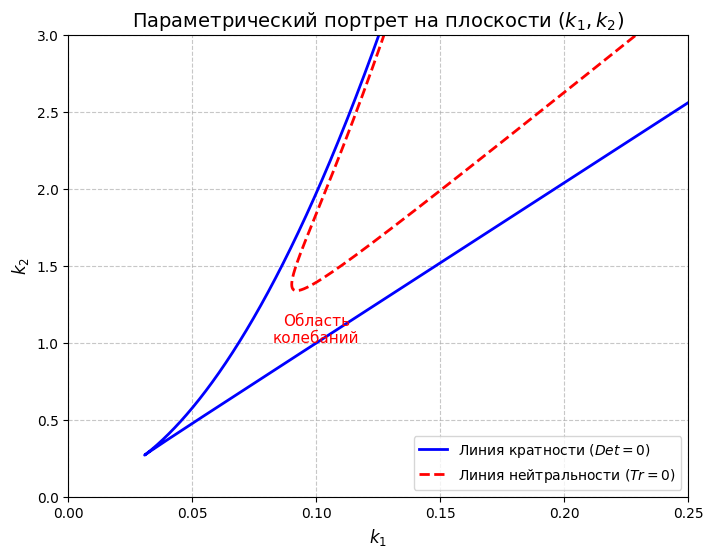

In [ ]:

# Выполнение пункта 1.3 (Двухпараметрический анализ)

def run_two_parameter_analysis():
    k1m = 0.01
    k3m = 0.002
    Sigma = k3 + k3m
    C = k3 / k3m
    x_max = 1.0 / (1.0 + C)
    
    x = np.linspace(0.001, x_max - 0.001, 10000)
    y = C * x
    z = 1.0 - x - y

    # --- Линия кратности (Det = 0) ---
    denom_det = (z**2) * (x * Sigma - z * k3m)
    with np.errstate(divide='ignore', invalid='ignore'):
        k2_det = (k1m * (x * Sigma + k3m * z)) / denom_det
        k1_det = (k1m * x + k2_det * (z**2) * x) / z

    valid_det = (k2_det > 0) & (k2_det < 5) & (k1_det > 0) & (k1_det < 0.5)
    k1_det_plot = np.where(valid_det, k1_det, np.nan)
    k2_det_plot = np.where(valid_det, k2_det, np.nan)

    # --- Линия нейтральности (Tr = 0) ---
    denom_tr = (z**2) * (x - z)
    with np.errstate(divide='ignore', invalid='ignore'):
        k2_tr = (k1m * (1 - y) + Sigma * z) / denom_tr
        k1_tr = (k1m * x + k2_tr * (z**2) * x) / z

    valid_tr = (k2_tr > 0) & (k2_tr < 5) & (k1_tr > 0) & (k1_tr < 0.5)
    k1_tr_plot = np.where(valid_tr, k1_tr, np.nan)
    k2_tr_plot = np.where(valid_tr, k2_tr, np.nan)

    # Построение графика
    plt.figure(figsize=(8, 6))
    plt.plot(k1_det_plot, k2_det_plot, 'b-', linewidth=2, label='Линия кратности ($Det=0$)')
    plt.plot(k1_tr_plot, k2_tr_plot, 'r--', linewidth=2, label='Линия нейтральности ($Tr=0$)')

    plt.title('Параметрический портрет на плоскости $(k_1, k_2)$', fontsize=14)
    plt.xlabel('$k_1$', fontsize=12)
    plt.ylabel('$k_2$', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(0.0, 0.25)
    plt.ylim(0.0, 3.0)
    
    # Отметка области возможных автоколебаний (внутри линии нейтральности)
    plt.text(0.1, 1.0, 'Область\nколебаний', fontsize=11, color='red', ha='center')
    
    plt.show()

run_two_parameter_analysis()